# import and load dataset

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt

from scipy.signal import detrend
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose, STL

In [8]:
df = pd.read_csv("retail_sales_mock_data.csv")
df.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [10]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df = df.asfreq("MS")

In [12]:
sns.set_theme(style="whitegrid")

# основной временной ряд
ts = df["SalesAmount"].astype(float).copy()

print("Период:", ts.index.min().date(), "—", ts.index.max().date())
print("Количество наблюдений:", len(ts))
print("Пропуски:", ts.isna().sum())
print(ts.describe())

Период: 2020-01-01 — 2023-12-01
Количество наблюдений: 48
Пропуски: 0
count       48.000000
mean     11768.541667
std       2257.544863
min       7783.000000
25%      10219.750000
50%      11851.000000
75%      13014.000000
max      17996.000000
Name: SalesAmount, dtype: float64


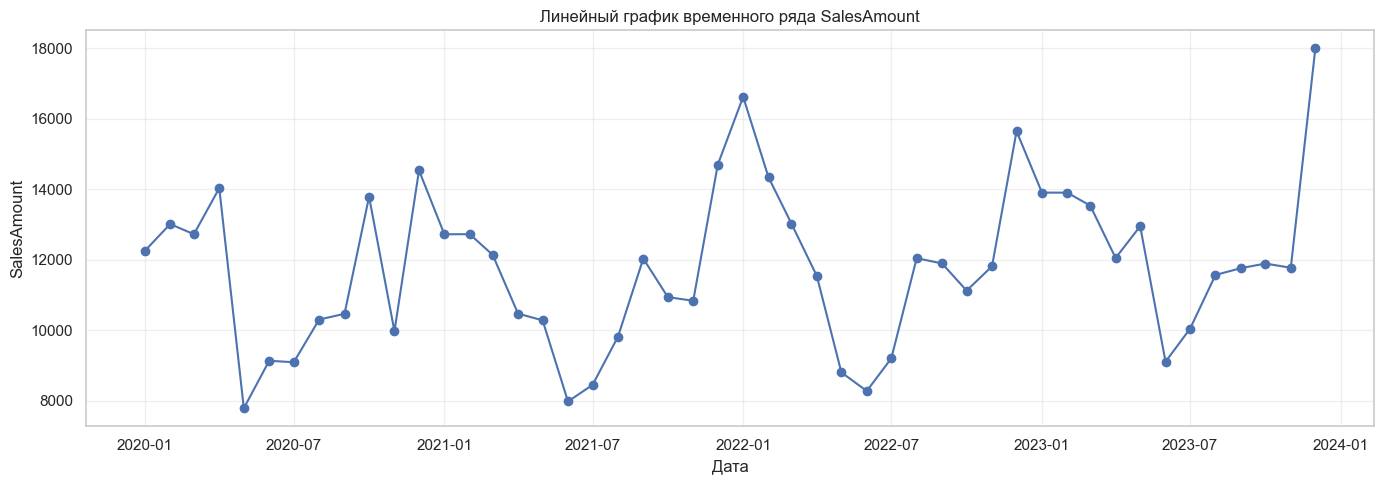

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts.values, marker="o")
plt.title("Линейный график временного ряда SalesAmount")
plt.xlabel("Дата")
plt.ylabel("SalesAmount")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

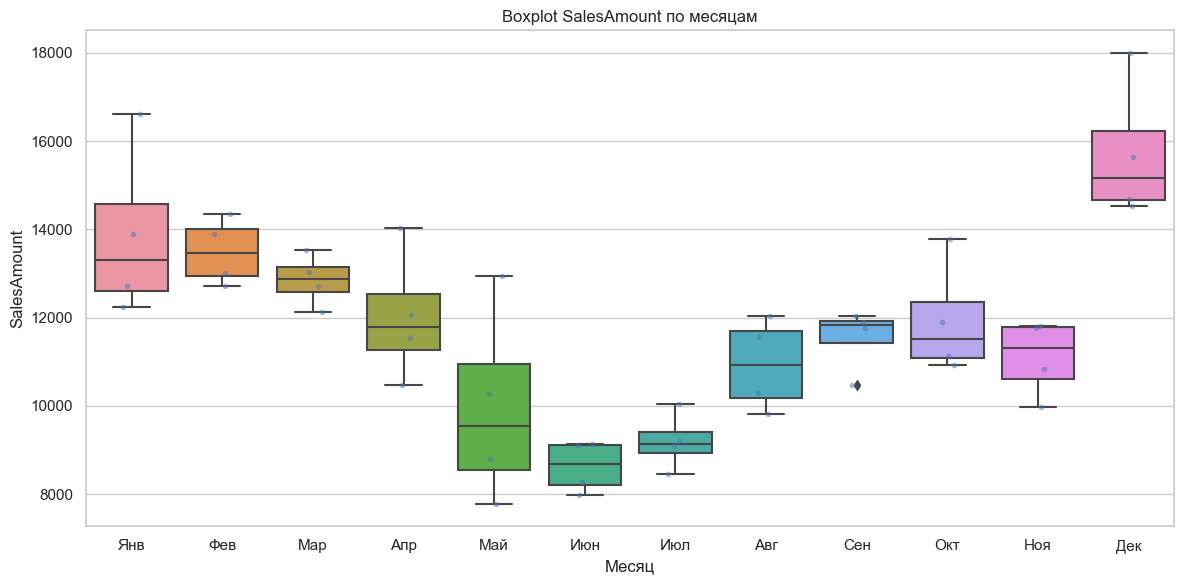

In [14]:
month_labels = {
    1: "Янв", 2: "Фев", 3: "Мар", 4: "Апр", 5: "Май", 6: "Июн",
    7: "Июл", 8: "Авг", 9: "Сен", 10: "Окт", 11: "Ноя", 12: "Дек"
}

box_df = ts.to_frame(name="SalesAmount")
box_df["MonthNum"] = box_df.index.month
box_df["Month"] = box_df["MonthNum"].map(month_labels)
box_df["Month"] = pd.Categorical(
    box_df["Month"],
    categories=list(month_labels.values()),
    ordered=True
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=box_df, x="Month", y="SalesAmount")
sns.stripplot(data=box_df, x="Month", y="SalesAmount", alpha=0.5, size=4)
plt.title("Boxplot SalesAmount по месяцам")
plt.xlabel("Месяц")
plt.ylabel("SalesAmount")
plt.tight_layout()
plt.show()

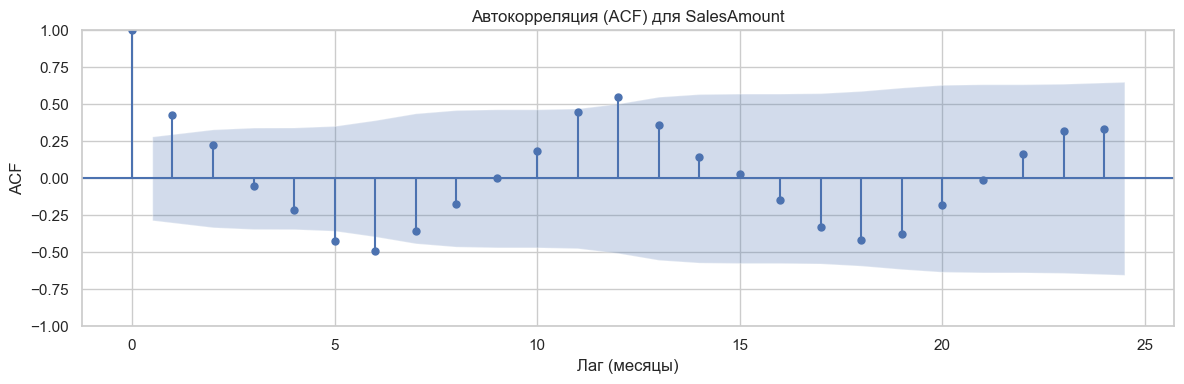

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(ts, lags=24, ax=ax)
ax.set_title("Автокорреляция (ACF) для SalesAmount")
ax.set_xlabel("Лаг (месяцы)")
ax.set_ylabel("ACF")
plt.tight_layout()
plt.show()

C:\Users\rshir\AppData\Local\Temp\ipykernel_14268\3542346994.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


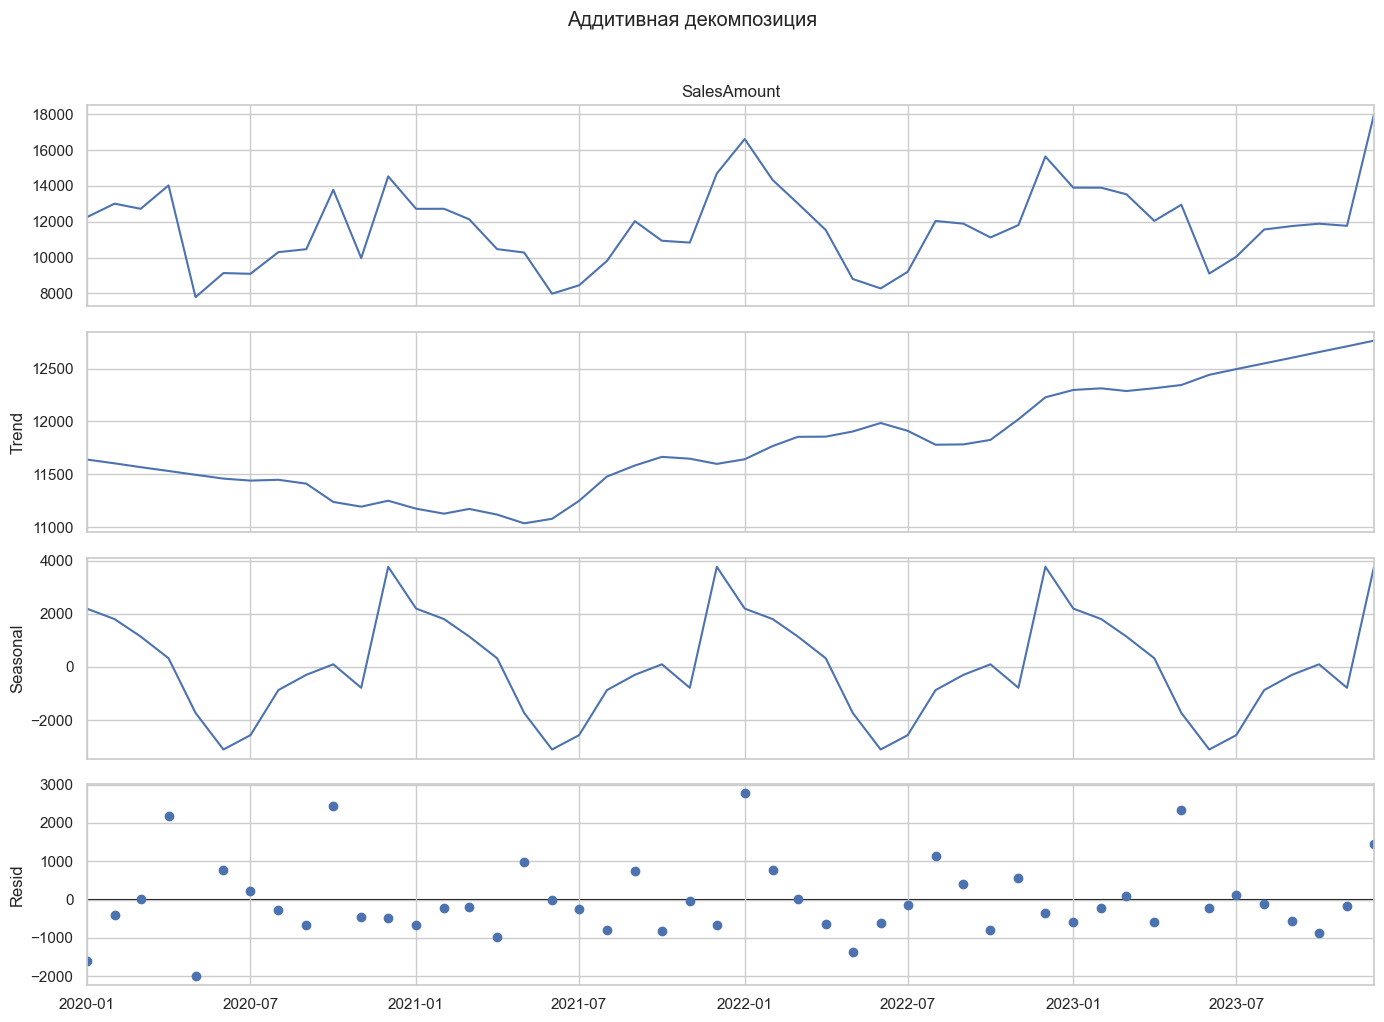

In [16]:
decomp_add = seasonal_decompose(
    ts,
    model="additive",
    period=12,
    extrapolate_trend="freq"
)

fig = decomp_add.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Аддитивная декомпозиция", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\rshir\AppData\Local\Temp\ipykernel_14268\3809937235.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


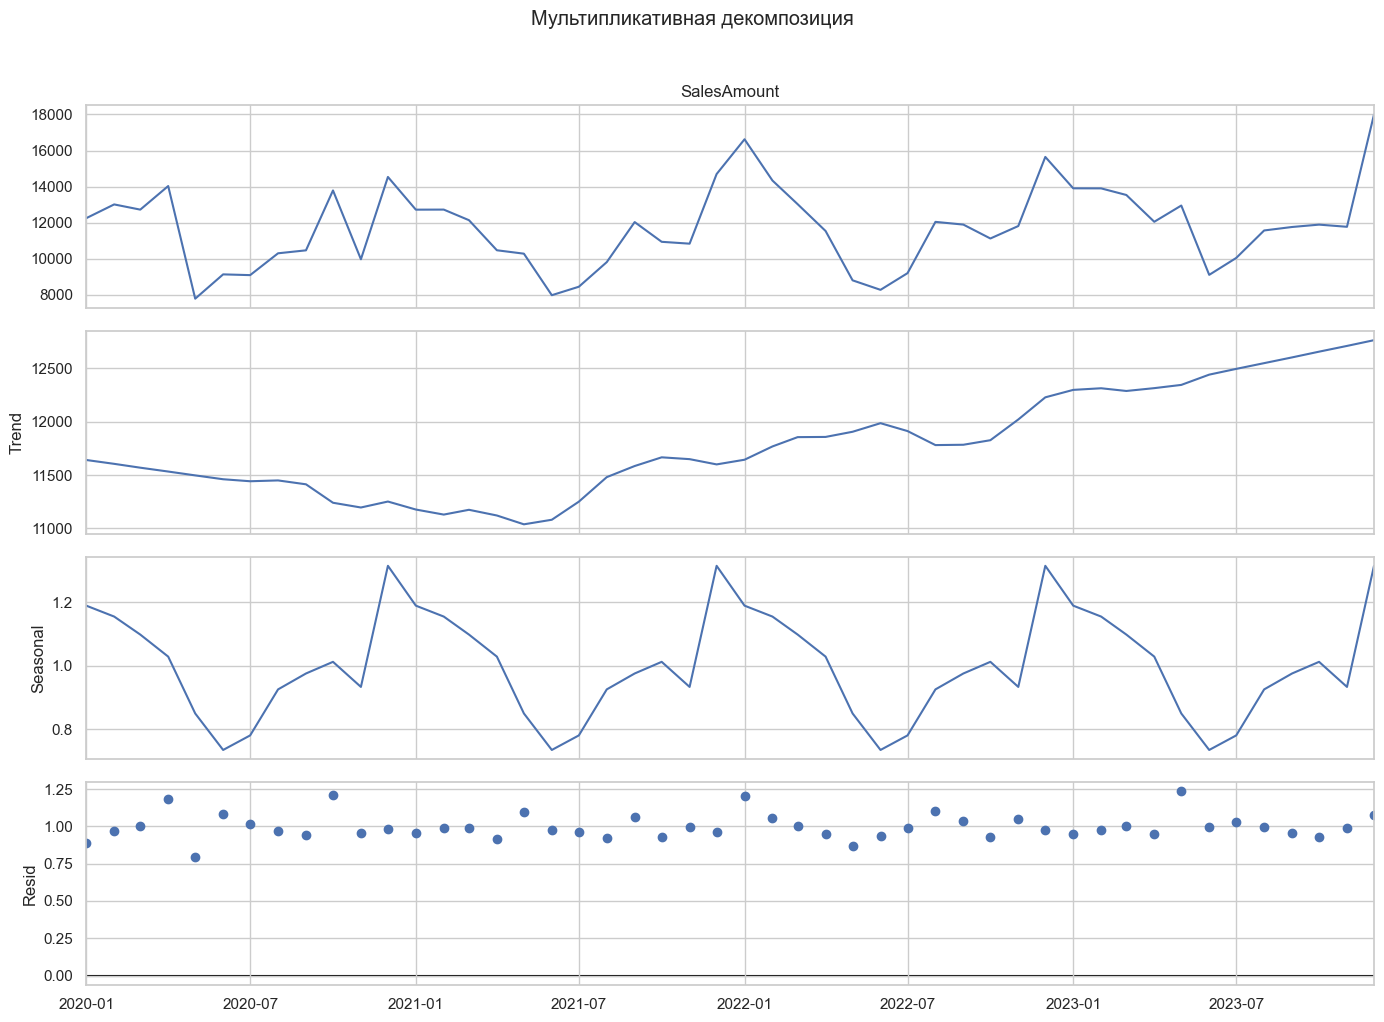

In [18]:
decomp_mul = seasonal_decompose(
    ts,
    model="multiplicative",
    period=12,
    extrapolate_trend="freq"
)

fig = decomp_mul.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Мультипликативная декомпозиция", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\rshir\AppData\Local\Temp\ipykernel_14268\118477572.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


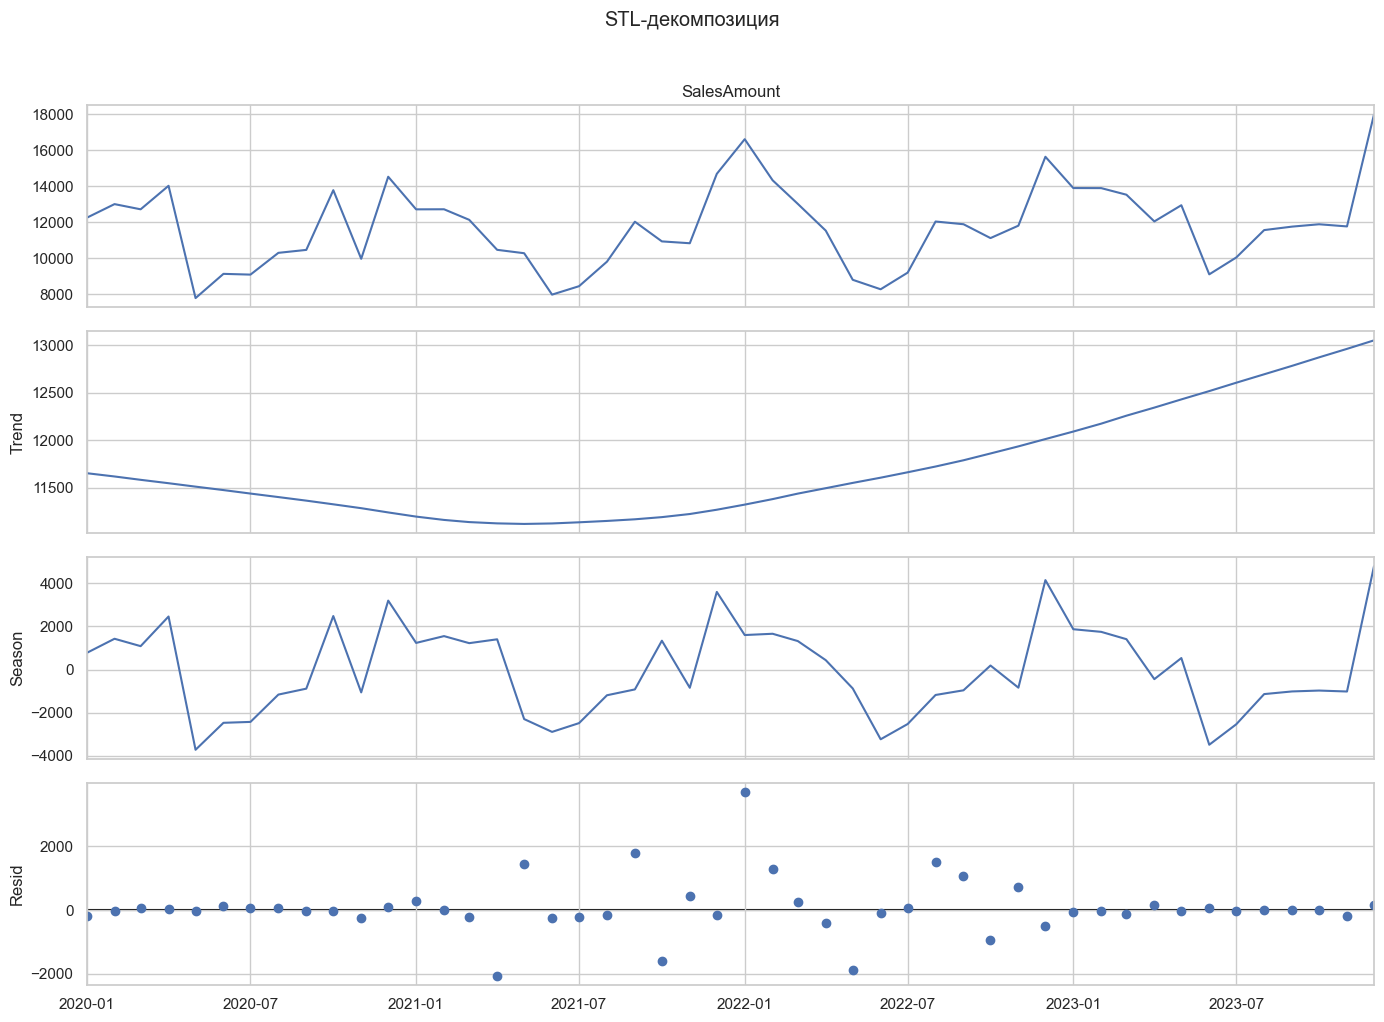

In [19]:
stl = STL(ts, period=12, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 10)
fig.suptitle("STL-декомпозиция", y=1.02)
plt.tight_layout()
plt.show()

    frequency_1_per_month  period_months         power
3                0.083333      12.000000  3.376921e+09
11               0.250000       4.000000  4.068245e+08
23               0.500000       2.000000  2.581354e+08
7                0.166667       6.000000  1.891419e+08
19               0.416667       2.400000  1.650044e+08
22               0.479167       2.086957  1.541550e+08
21               0.458333       2.181818  1.520215e+08
12               0.270833       3.692308  1.270382e+08
13               0.291667       3.428571  1.178903e+08
15               0.333333       3.000000  1.176958e+08


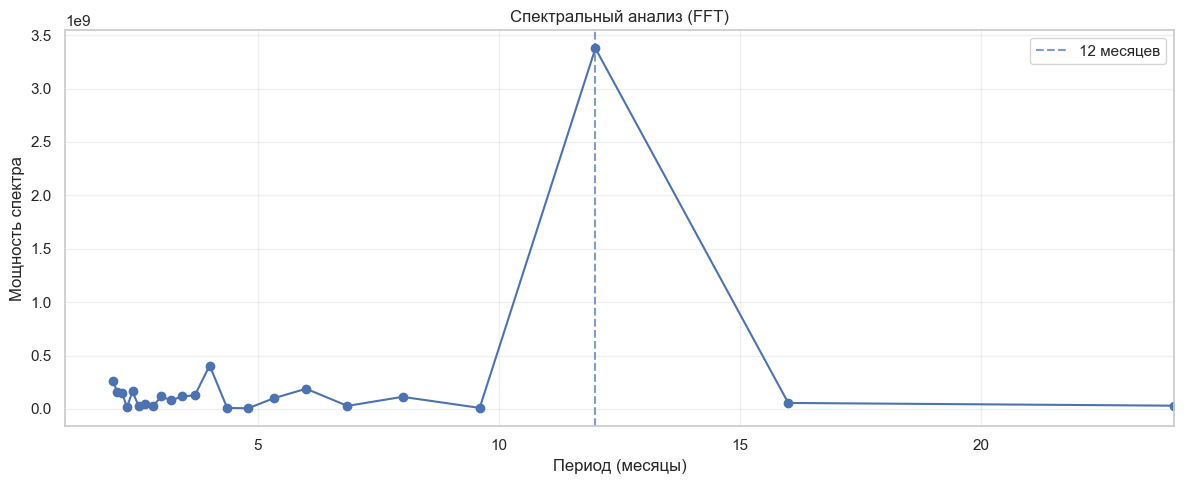

In [20]:
y = ts.values
y_detrended = detrend(y)   # убираем тренд перед спектральным анализом
n = len(y_detrended)

fft_vals = np.fft.rfft(y_detrended)
freqs = np.fft.rfftfreq(n, d=1)   # шаг = 1 месяц
power = np.abs(fft_vals) ** 2

mask = freqs > 0
freqs_nonzero = freqs[mask]
power_nonzero = power[mask]
periods = 1 / freqs_nonzero

# топ основных периодов
fft_peaks = pd.DataFrame({
    "frequency_1_per_month": freqs_nonzero,
    "period_months": periods,
    "power": power_nonzero
}).sort_values("power", ascending=False)

print(fft_peaks.head(10))

sort_idx = np.argsort(periods)

plt.figure(figsize=(12, 5))
plt.plot(periods[sort_idx], power_nonzero[sort_idx], marker="o")
plt.axvline(12, linestyle="--", alpha=0.7, label="12 месяцев")
plt.xlim(1, 24)
plt.title("Спектральный анализ (FFT)")
plt.xlabel("Период (месяцы)")
plt.ylabel("Мощность спектра")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

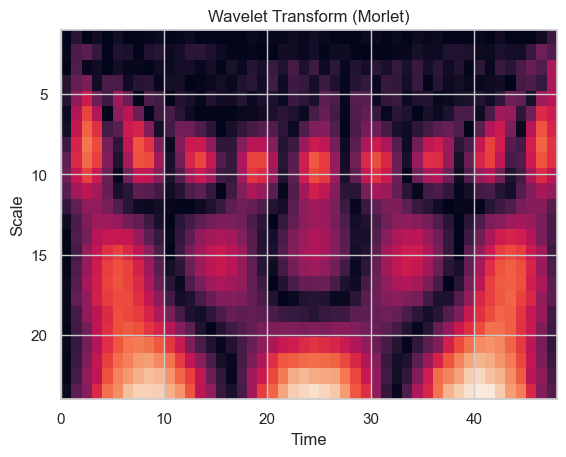

In [25]:
scales = np.arange(1, 25)

coefficients, frequencies = pywt.cwt(
    df["SalesAmount"],
    scales,
    'morl'
)

plt.figure()
plt.imshow(
    np.abs(coefficients),
    extent=[0, len(df), scales.max(), scales.min()],
    aspect='auto'
)
plt.title("Wavelet Transform (Morlet)")
plt.ylabel("Scale")
plt.xlabel("Time")
plt.show()

### Линейный график временного ряда
По линейному графику видно, что ряд изменяется не хаотично, а по повторяющемуся годовому сценарию. В начале и конце года продажи выше, а в середине года наблюдается снижение. Также заметен умеренный рост к концу рассматриваемого периода.

### Boxplot по месяцам
Boxplot подтверждает наличие сезонности. Наиболее высокие значения характерны для декабря, января и февраля, а наиболее низкие — для июня и июля. Это говорит о стабильных различиях между месяцами.

### Автокорреляция
График автокорреляции показывает выраженный пик на лаге 12 месяцев, что указывает на годовую сезонность. Также наблюдается отрицательная связь примерно на лаге 6 месяцев, что отражает противоположные фазы внутри года.

### Аддитивная модель
Аддитивная декомпозиция показывает, что ряд можно представить как сумму тренда, сезонности и случайной компоненты. Сезонная составляющая устойчива, а тренд сначала снижается, а затем переходит в рост.

### Мультипликативная модель
Мультипликативная модель также хорошо описывает ряд. Она показывает, что сезонные колебания можно интерпретировать в относительных величинах: в сильные месяцы продажи выше тренда, а в слабые — ниже.

### STL-декомпозиция
STL-декомпозиция наиболее наглядно выделяет тренд и сезонность. Она подтверждает наличие устойчивой повторяющейся сезонной структуры и показывает, что после снижения до 2021 года ряд переходит к росту.

### Спектральный анализ (FFT)
FFT выявил доминирующий период около 12 месяцев. Это подтверждает, что основной цикл ряда является годовым. Более короткие периоды также присутствуют, но выражены значительно слабее.

### Вейвлет-анализ
Вейвлет-анализ показывает, что повторяющаяся структура сохраняется на протяжении почти всего интервала наблюдений. Это подтверждает устойчивость сезонности во времени.

# Построение прогнозных моделей

In [26]:
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Целевой ряд
y = df["SalesAmount"].astype(float).asfreq("MS")

# Экзогенная переменная
# HolidayMonth не берем, потому что годовая сезонность уже учитывается через seasonal_order=(..., 12)
exog = df[["Promotion"]].astype(float).asfreq("MS")

# Train / test: последние 12 месяцев в test
test_h = 12
y_train, y_test = y.iloc[:-test_h], y.iloc[-test_h:]
exog_train, exog_test = exog.iloc[:-test_h], exog.iloc[-test_h:]

print("Train size:", len(y_train))
print("Test size:", len(y_test))

Train size: 36
Test size: 12


In [27]:
def adf_test(series, name="series"):
    s = series.dropna()
    stat, pvalue, *_ = adfuller(s, autolag="AIC")
    print(f"{name:<28} stat={stat:>8.3f}, p-value={pvalue:.4f}")

print("ADF-тест:")
adf_test(y_train, "y_train")
adf_test(y_train.diff(), "diff(y_train)")
adf_test(y_train.diff(12), "seasonal_diff_12(y_train)")
adf_test(y_train.diff().diff(12), "diff + seasonal_diff")

ADF-тест:
y_train                      stat=  -3.770, p-value=0.0032
diff(y_train)                stat=  -4.593, p-value=0.0001
seasonal_diff_12(y_train)    stat=  -1.552, p-value=0.5078
diff + seasonal_diff         stat=  -1.410, p-value=0.5776


In [28]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [29]:
# Подобранные параметры под твой ряд
arima_order = (1, 1, 3)

sarimax_order = (2, 1, 2)
sarimax_seasonal_order = (0, 1, 1, 12)

In [30]:
arima_model = SARIMAX(
    y_train,
    order=arima_order,
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

arima_res = arima_model.fit(disp=False)

arima_forecast = arima_res.get_forecast(steps=len(y_test))
arima_pred = arima_forecast.predicted_mean
arima_ci = arima_forecast.conf_int()

arima_metrics = calc_metrics(y_test, arima_pred)

print("ARIMA metrics:")
for k, v in arima_metrics.items():
    print(f"{k}: {v:.2f}")

ARIMA metrics:
MAE: 1240.13
RMSE: 2106.56
MAPE: 9.44


In [31]:
sarimax_model = SARIMAX(
    y_train,
    exog=exog_train,
    order=sarimax_order,
    seasonal_order=sarimax_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_res = sarimax_model.fit(disp=False)

sarimax_forecast = sarimax_res.get_forecast(
    steps=len(y_test),
    exog=exog_test
)

sarimax_pred = sarimax_forecast.predicted_mean
sarimax_ci = sarimax_forecast.conf_int()

sarimax_metrics = calc_metrics(y_test, sarimax_pred)

print("SARIMAX metrics:")
for k, v in sarimax_metrics.items():
    print(f"{k}: {v:.2f}")

SARIMAX metrics:
MAE: 544.14
RMSE: 832.08
MAPE: 4.06


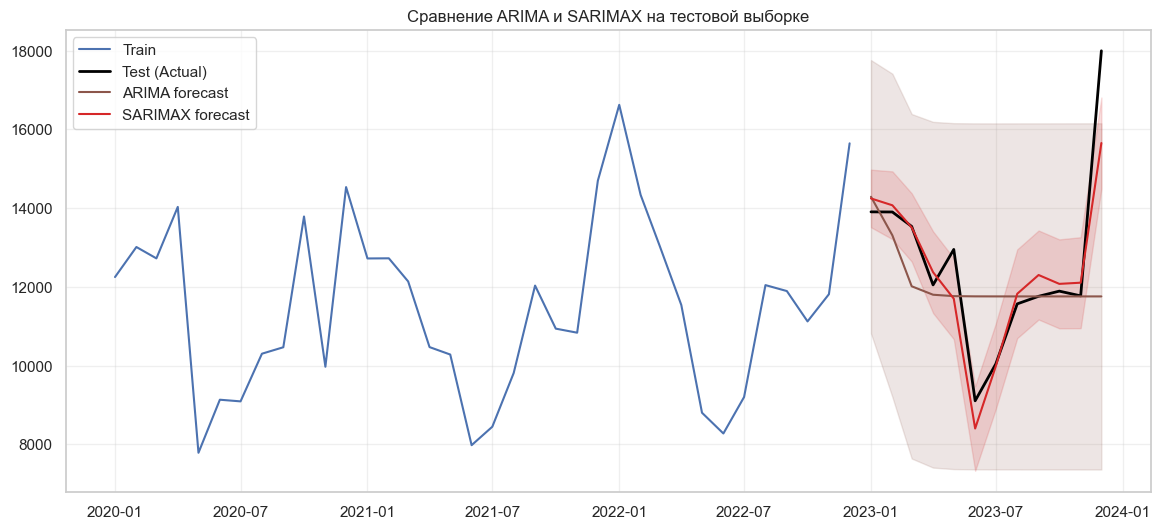

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test (Actual)", color="black", linewidth=2)

plt.plot(y_test.index, arima_pred, label="ARIMA forecast", color="tab:brown")
plt.plot(y_test.index, sarimax_pred, label="SARIMAX forecast", color="tab:red")

plt.fill_between(
    arima_ci.index,
    arima_ci.iloc[:, 0],
    arima_ci.iloc[:, 1],
    color="tab:brown",
    alpha=0.15
)

plt.fill_between(
    sarimax_ci.index,
    sarimax_ci.iloc[:, 0],
    sarimax_ci.iloc[:, 1],
    color="tab:red",
    alpha=0.15
)

plt.title("Сравнение ARIMA и SARIMAX на тестовой выборке")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
final_model = SARIMAX(
    y,
    exog=exog,
    order=sarimax_order,
    seasonal_order=sarimax_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_res = final_model.fit(disp=False)

In [35]:
horizon = 12

future_index = pd.date_range(
    start=y.index[-1] + pd.offsets.MonthBegin(1),
    periods=horizon,
    freq="MS"
)

# Базовый сценарий: в будущем промо-акций нет
future_exog = pd.DataFrame(
    {"Promotion": 0},
    index=future_index
)

future_forecast = final_res.get_forecast(
    steps=horizon,
    exog=future_exog
)

future_pred = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

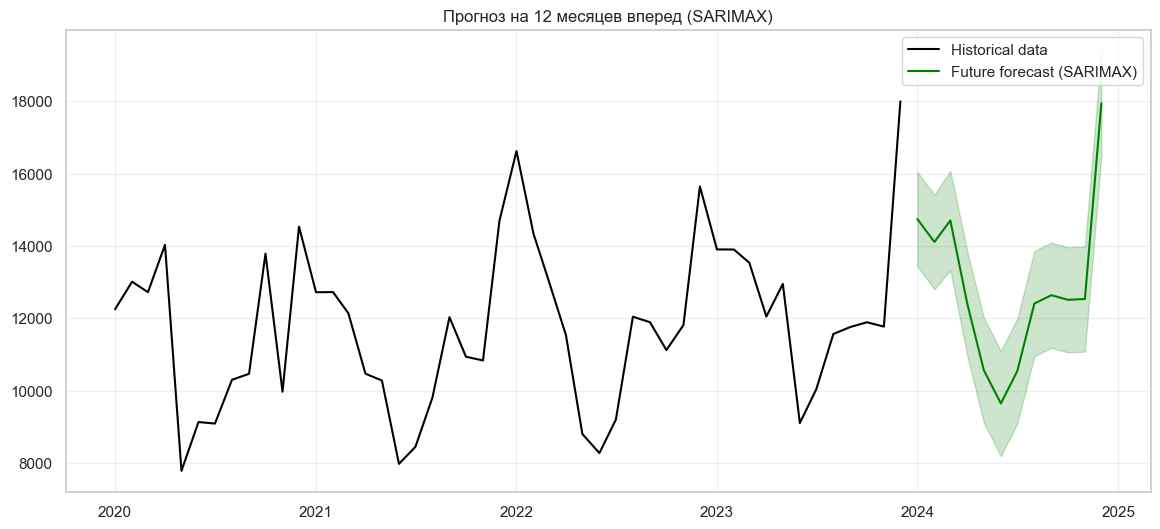

In [36]:
plt.figure(figsize=(14, 6))

plt.plot(y.index, y, label="Historical data", color="black")
plt.plot(future_pred.index, future_pred, label="Future forecast (SARIMAX)", color="green")

plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    color="green",
    alpha=0.2
)

plt.title("Прогноз на 12 месяцев вперед (SARIMAX)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Метрики

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import shapiro, jarque_bera
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

In [40]:
comparison_df = pd.DataFrame({
    "Model": ["ARIMA", "SARIMAX"],
    "MSE": [
        mean_squared_error(y_test, arima_pred),
        mean_squared_error(y_test, sarimax_pred)
    ],
    "R2": [
        r2_score(y_test, arima_pred),
        r2_score(y_test, sarimax_pred)
    ],
    "AIC": [
        arima_res.aic,
        sarimax_res.aic
    ],
    "BIC": [
        arima_res.bic,
        sarimax_res.bic
    ]
}).set_index("Model")

comparison_df.round(4)

,MSE,R2,AIC,BIC
Model,,,,
ARIMA,4.437585e+06,0.0405,563.8572,571.0272
SARIMAX,6.923547e+05,0.8503,131.7313,132.2874


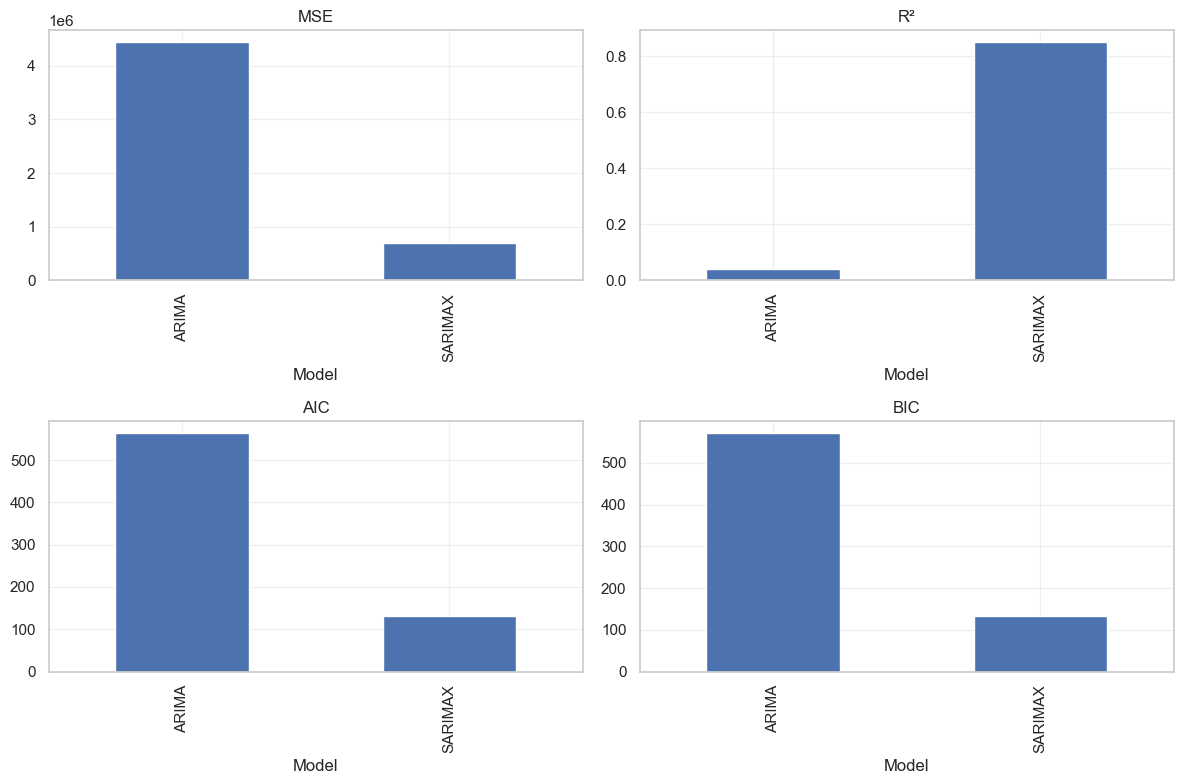

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

comparison_df["MSE"].plot(kind="bar", ax=axes[0, 0], title="MSE")
axes[0, 0].grid(True, alpha=0.3)

comparison_df["R2"].plot(kind="bar", ax=axes[0, 1], title="R²")
axes[0, 1].grid(True, alpha=0.3)

comparison_df["AIC"].plot(kind="bar", ax=axes[1, 0], title="AIC")
axes[1, 0].grid(True, alpha=0.3)

comparison_df["BIC"].plot(kind="bar", ax=axes[1, 1], title="BIC")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
def get_model_residuals(result, drop_first=True):
    resid = pd.Series(result.resid).dropna()

    # первая точка у интегрированных моделей часто искажена инициализацией
    if drop_first and len(resid) > 1:
        resid = resid.iloc[1:]

    return resid


def residual_tests(result, model_name, lb_lag=12, arch_lag=6):
    resid = get_model_residuals(result)

    shapiro_p = shapiro(resid).pvalue
    jb_p = jarque_bera(resid).pvalue
    ljungbox_p = acorr_ljungbox(resid, lags=[lb_lag], return_df=True)["lb_pvalue"].iloc[0]
    arch_p = het_arch(resid, nlags=arch_lag)[1]

    return {
        "Model": model_name,
        "Shapiro_p": shapiro_p,
        "Jarque_Bera_p": jb_p,
        "Ljung_Box_p": ljungbox_p,
        "ARCH_p": arch_p,
        "Normal_by_Shapiro": shapiro_p > 0.05,
        "Normal_by_JB": jb_p > 0.05,
        "No_autocorr": ljungbox_p > 0.05,
        "Homoskedastic": arch_p > 0.05
    }

In [44]:
residuals_df = pd.DataFrame([
    residual_tests(arima_res, "ARIMA"),
    residual_tests(sarimax_res, "SARIMAX")
]).set_index("Model")

residuals_df.round(4)

,Shapiro_p,Jarque_Bera_p,Ljung_Box_p,ARCH_p,Normal_by_Shapiro,Normal_by_JB,No_autocorr,Homoskedastic
Model,,,,,,,,
ARIMA,0.0103,0.271,0.1740,0.4013,False,True,True,True
SARIMAX,0.0004,0.000,0.6666,0.7917,False,False,True,True


In [48]:
def get_model_residuals(result, drop_first=True):
    resid = pd.Series(result.resid).dropna()

    if drop_first and len(resid) > 1:
        resid = resid.iloc[1:]

    # на всякий случай приводим индекс к datetime
    if isinstance(resid.index, pd.PeriodIndex):
        resid.index = resid.index.to_timestamp()
    elif not isinstance(resid.index, pd.DatetimeIndex):
        resid.index = pd.to_datetime(resid.index)

    return resid


def format_date_axis(ax, interval=6, fmt="%Y-%m"):
    locator = mdates.MonthLocator(interval=interval)
    formatter = mdates.DateFormatter(fmt)

    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment("right")


def plot_residual_diagnostics(result, title):
    resid = get_model_residuals(result)

    fig, axes = plt.subplots(2, 3, figsize=(17, 9))

    # 1. Остатки во времени
    axes[0, 0].plot(resid.index, resid)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title(f"{title}: остатки")
    axes[0, 0].grid(True, alpha=0.3)
    format_date_axis(axes[0, 0], interval=6)

    # 2. Гистограмма
    axes[0, 1].hist(resid, bins=10)
    axes[0, 1].set_title(f"{title}: гистограмма остатков")
    axes[0, 1].grid(True, alpha=0.3)

    # 3. QQ-plot
    sm.qqplot(resid, line="s", ax=axes[0, 2])
    axes[0, 2].set_title(f"{title}: QQ-plot")

    # 4. ACF остатков
    plot_acf(resid, lags=12, ax=axes[1, 0])
    axes[1, 0].set_title(f"{title}: ACF остатков")
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Квадраты остатков
    axes[1, 1].plot(resid.index, resid**2)
    axes[1, 1].set_title(f"{title}: квадраты остатков")
    axes[1, 1].grid(True, alpha=0.3)
    format_date_axis(axes[1, 1], interval=6)

    # 6. Скользящее стандартное отклонение
    rolling_std = resid.rolling(window=6).std()
    axes[1, 2].plot(rolling_std.index, rolling_std)
    axes[1, 2].set_title(f"{title}: rolling std (окно=6)")
    axes[1, 2].grid(True, alpha=0.3)
    format_date_axis(axes[1, 2], interval=6)

    plt.tight_layout()
    plt.show()

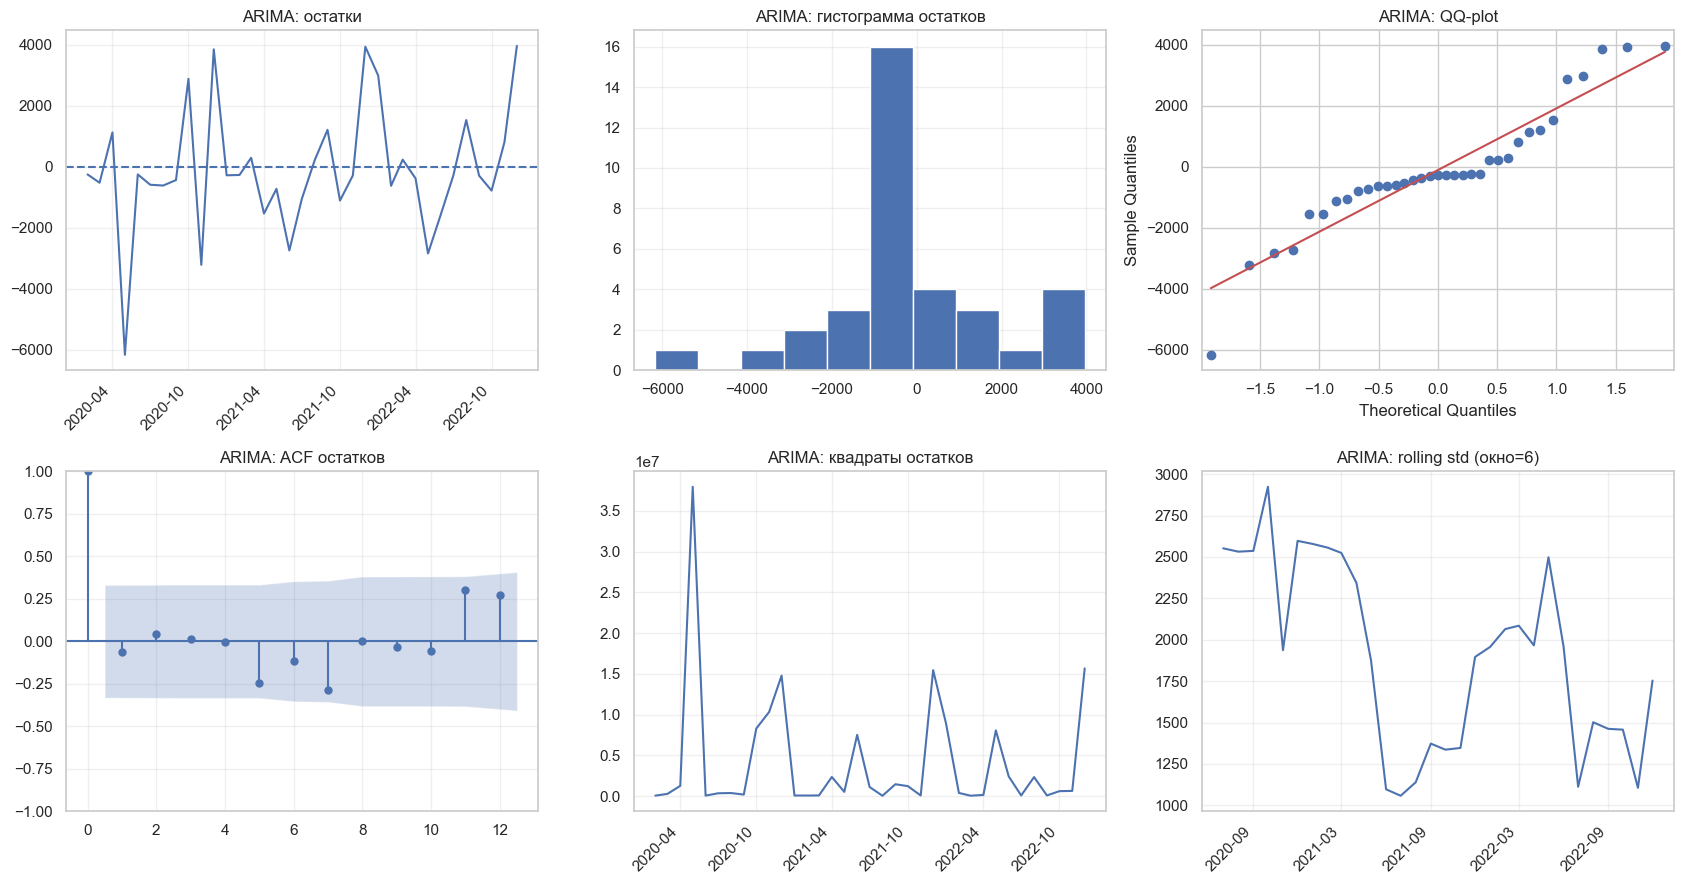

In [49]:
plot_residual_diagnostics(arima_res, "ARIMA")

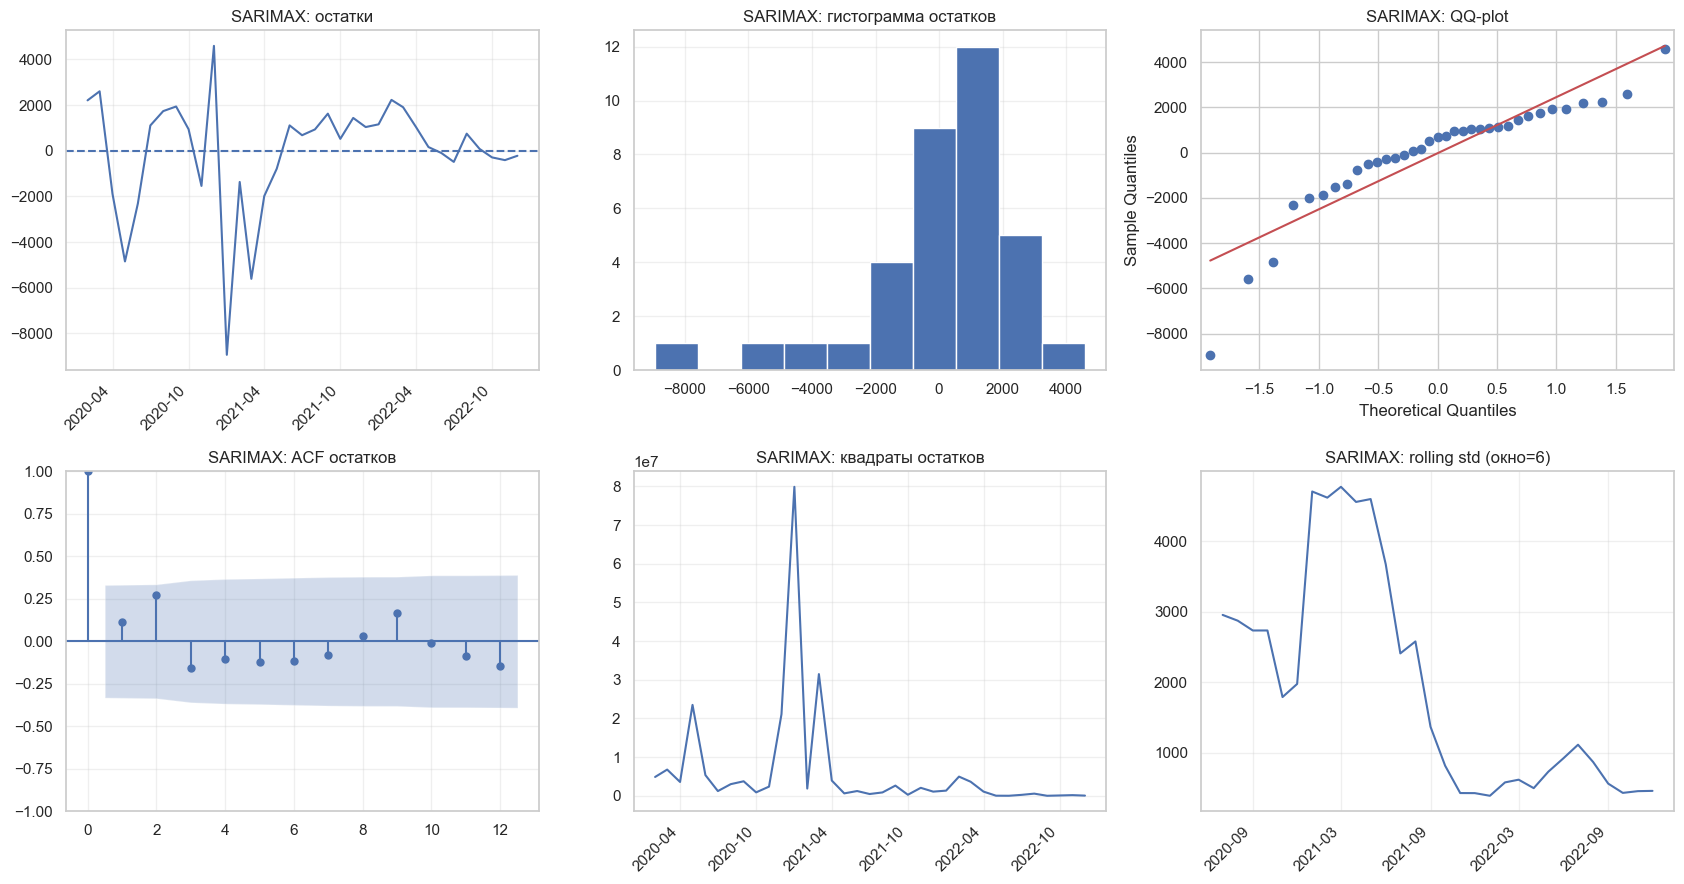

In [50]:
plot_residual_diagnostics(sarimax_res, "SARIMAX")

## 2.3. Оценка качества моделей

По результатам расчета метрик качества модель SARIMAX показала значительно более высокую точность прогноза по сравнению с ARIMA. Для SARIMAX значение MSE оказалось существенно ниже, а коэффициент детерминации R² — значительно выше, что говорит о лучшем соответствии прогнозных значений фактическим данным.

Сравнение по информационным критериям также показало преимущество модели SARIMAX: значения AIC и BIC у нее ниже, чем у ARIMA. Это свидетельствует о лучшем балансе между качеством подгонки и сложностью модели.

Анализ остатков показал, что у обеих моделей не наблюдается статистически значимой автокорреляции остатков, а также отсутствуют явные признаки гетероскедастичности. При этом нормальность распределения остатков выполняется не полностью, особенно для модели SARIMAX, что указывает на наличие отдельных выбросов или асимметрии распределения ошибок. Однако с практической точки зрения это не отменяет преимущества SARIMAX, так как по основным прогнозным метрикам и информационным критериям она превосходит ARIMA.

Таким образом, предпочтительной моделью для данного временного ряда является **SARIMAX**, поскольку она обеспечивает более точный прогноз, лучше учитывает сезонность и влияние внешних факторов, а также демонстрирует лучшие значения AIC и BIC.